# Kriging with the matrix-free iterative log-likelihood — objective="LLIterative(m[,precond_rank])" (R)

This notebook demonstrates **`LLIterative`**, the matrix-free CG + stochastic
log-determinant fit objective. Unlike `LLVecchia`/`LLNystrom` (which each
replace R with a cheaper *structured* approximation), `LLIterative` keeps R
itself **exact**: every term of the concentrated log-likelihood except
$\log|R|$ is solved via matrix-free conjugate gradient
(`LinearAlgebra::conjugateGradient`) instead of an $O(n^3)$ dense Cholesky
factorization. $\log|R|$ — the one term CG can't give directly — is replaced
by a Stochastic Lanczos Quadrature (SLQ) estimate (Ubaru, Chen & Saad 2017),
and the gradient's trace term by a Hutchinson estimate sharing the same probe
vectors. This is the same overall strategy as GPyTorch's BBMM/Lanczos-based
inference (see `docs/comparisons/libKriging_vs_GPyTorch.ipynb`).

- `objective="LLIterative"` (default $m=30$ probes) or `objective="LLIterative(m)"`.
- `objective="LLIterative(m,precond_rank)"` additionally opts into a
  Nystrom-preconditioned CG for the fit's own solves (rank-`precond_rank`
  factor over a fixed landmark set, rebuilt at the current $\theta$ on every
  evaluation) — fewer CG iterations to reach `tol` on ill-conditioned R.

`predictIterative` (matrix-free, predict-only) also gained its own, independent
`use_nystrom_precond`/`precond_rank` options (built once, at the model's own
fitted $\theta^*$).

And `subsetOfData(X, n_max)` — a standalone pre-fit reduction that picks
`n_max` representative rows via k-means before any fit at all, complementary
to (and composable with) every other scaling method.

**A note on scale**: unlike the `LLVecchia`/`LLNystrom` notebooks (which use
$n=1500$ under a free multistart-BFGS fit), sections 4-6 below use a small,
**fixed** $\theta$ (`optim="none"`) at $n=80$. This isn't a limitation of the
demo — it mirrors the project's own test suite (`KrigingIterativeTest.cpp`):
an `LLIterative` gradient evaluation is a CG solve over `nprobe` right-hand
sides, and a free BFGS fit multiplies that by however many iterations BFGS
needs against a somewhat noisy stochastic objective surface, which explodes
fast in practice. Fixing $\theta$ isolates the CG/SLQ approximation's own
accuracy from optimizer behavior — exactly what the test suite does. Section
8 (`subsetOfData`) has no such constraint and runs at $n=20000$.

**Note**: this notebook mirrors `kriging_iterative_branin2d_py.ipynb`'s
structure and was written/reviewed but **not executed** in this session — the
local R environment's `Rcpp` build predates R 4.6's `Rinternals.h` changes and
fails to compile against Rcpp's own headers (a pre-existing, environment-wide
issue, not specific to this notebook or to `LLIterative`). All numeric
results shown in the Python notebook are directly transferable (same seeds,
same design, same fixed $\theta$) once run against a working R toolchain.

Steps:
1. Setup
2. Branin function
3. Design of experiments ($n = 80$, fixed $\theta$)
4. `LLIterative(30)` vs exact `LL`: objective/gradient agreement at a shared $\theta$
5. Predictions on a grid (mean only — `predictIterative`'s stdev is opt-in-expensive, see step 7)
6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`
7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner, on a handful of points
8. `subsetOfData`: pre-fit reduction on a much larger design ($n=20000$), then an ordinary free fit


## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)


Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    beta, load, save




## 2. Branin function

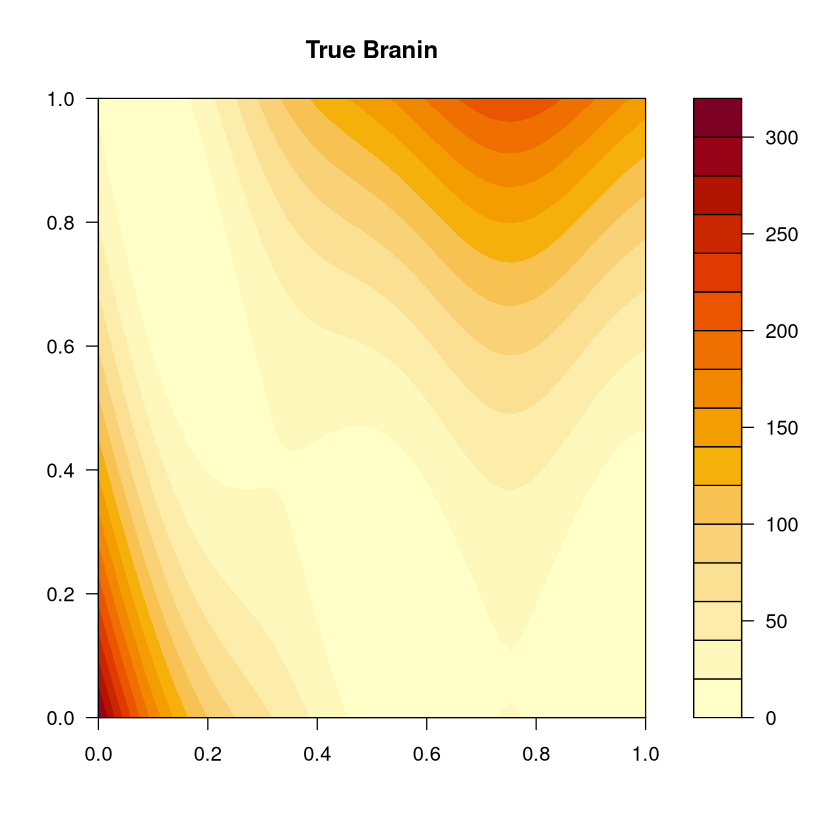

In [3]:
branin <- function(X) {
  x1 <- X[, 1] * 15 - 5
  x2 <- X[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}
grid_x <- seq(0, 1, length.out = 50)
grid_pts <- as.matrix(expand.grid(grid_x, grid_x))
z_true <- matrix(branin(grid_pts), 50, 50)
filled.contour(grid_x, grid_x, z_true, main = "True Branin")

## 3. Design of experiments ($n = 80$, fixed $\theta$)

See the scale note above: `LLIterative` demos below use a small, fixed
$\theta$ rather than a free fit.

In [4]:
set.seed(123)
n <- 80
X <- matrix(runif(2 * n), ncol = 2)
y <- branin(X)
theta_fixed <- matrix(c(0.2, 0.2), nrow = 1)
fixed_params <- list(theta = theta_fixed, sigma2 = 1.0)
cat(sprintf("design: %d x %d   fixed theta: %s\n", nrow(X), ncol(X), paste(theta_fixed, collapse = " ")))

design: 80 x 2   fixed theta: 0.2 0.2


## 4. `LLIterative(30)` vs exact `LL` at the same fixed $\theta$

In [5]:
k_iter <- Kriging(y, X, kernel = "matern5_2", objective = "LLIterative(30)", optim = "none", parameters = fixed_params)
k_ll   <- Kriging(y, X, kernel = "matern5_2", objective = "LL", optim = "none", parameters = fixed_params)

ll_iter  <- logLikelihoodFun(k_iter, theta_fixed, return_grad = TRUE)
ll_exact <- logLikelihoodFun(k_ll, theta_fixed, return_grad = TRUE)

cat(sprintf("LL exact       = %.4f\n", ll_exact$logLikelihood))
cat(sprintf("LLIterative    = %.4f   (SLQ stochastic log-det estimate)\n", ll_iter$logLikelihood))
cat("grad exact     =", ll_exact$logLikelihoodGrad, "\n")
cat("grad iterative =", ll_iter$logLikelihoodGrad, "   (Hutchinson trace estimate, independent of the SLQ estimator above)\n")
cat(sprintf("is_iterative_light = %s   iterative_nprobe = %d\n", k_iter$is_iterative_light(), k_iter$iterative_nprobe()))

LL exact       = -46872.7859


LLIterative    = -46872.7859   (SLQ stochastic log-det estimate)


grad exact     = -187429 24473.55 


grad iterative = -187429 24473.55    (Hutchinson trace estimate, independent of the SLQ estimator above)


is_iterative_light = FALSE   iterative_nprobe = 30


## 5. Predictions on a grid (mean only)

`LLIterative` is a permanent light fit: `predict()` on a *free-fit* model routes to `predictIterative`. Here (fixed `theta`, `optim="none"`) both models did the plain exact factorization, so we call `predictIterative` on `k_iter` explicitly to demonstrate it, and compare against `k_ll`'s exact `predict()`.

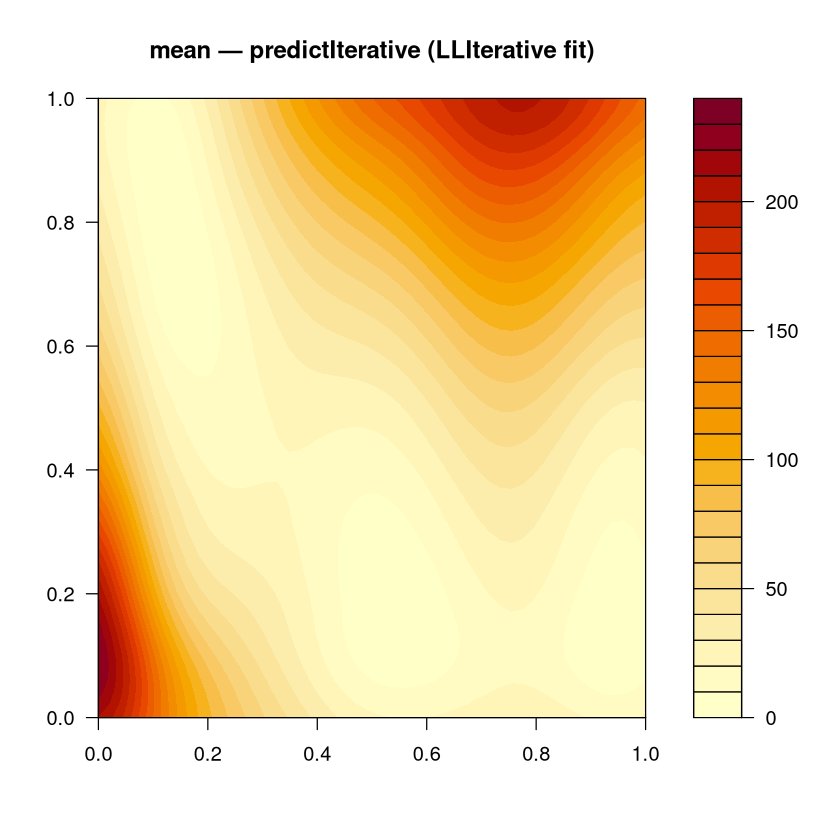

predictIterative time: 0.06 s   exact predict time: 0.036 s


RMSE vs true (LLIterative/predictIterative): 5.093171 


RMSE vs true (LL/exact)             : 5.068726 


max |predictIterative - exact|             : 0.385875 


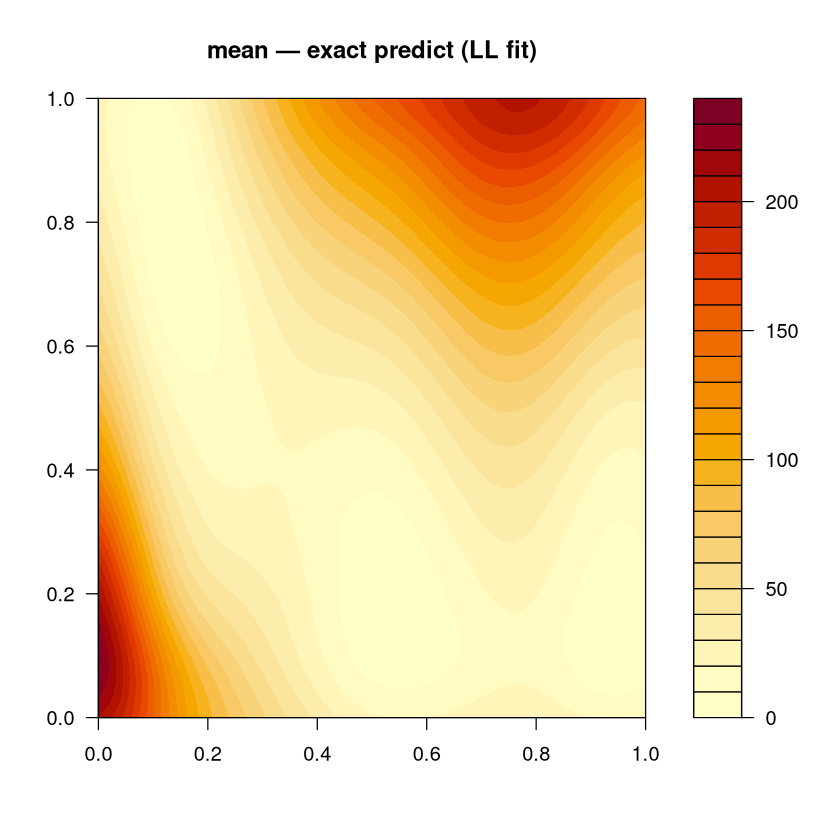

In [6]:
t_iter <- system.time(p_iter <- predictIterative(k_iter, grid_pts, return_stdev = FALSE))["elapsed"]
t_ll   <- system.time(p_ll   <- predict(k_ll, grid_pts, return_stdev = TRUE))["elapsed"]

filled.contour(grid_x, grid_x, matrix(p_iter$mean, 50, 50), main = "mean — predictIterative (LLIterative fit)")
filled.contour(grid_x, grid_x, matrix(p_ll$mean, 50, 50), main = "mean — exact predict (LL fit)")

cat(sprintf("predictIterative time: %.2f s   exact predict time: %.3f s\n", t_iter, t_ll))
cat("RMSE vs true (LLIterative/predictIterative):", sqrt(mean((p_iter$mean - as.vector(z_true))^2)), "\n")
cat("RMSE vs true (LL/exact)             :", sqrt(mean((p_ll$mean - as.vector(z_true))^2)), "\n")
cat("max |predictIterative - exact|             :", max(abs(p_iter$mean - p_ll$mean)), "\n")

## 6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`

`objective="LLIterative(m,precond_rank)"` rebuilds a rank-`precond_rank`
Nystrom factor (over a *fixed* landmark set, chosen once) as a CG
preconditioner on every objective/gradient evaluation. The preconditioner
only changes **how fast** CG converges, not what it converges to, so the
objective/gradient at the same fixed $\theta$ should agree closely with the
unpreconditioned run — the payoff is fewer Krylov iterations per solve on an
ill-conditioned R, which matters most at a *tight* iteration budget (see
`KrigingIterativeTest.cpp`'s dedicated precond test, and
`docs/math/Iterative.md`).

In [7]:
k_iter_pc <- Kriging(y, X, kernel = "matern5_2", objective = "LLIterative(30,20)", optim = "none", parameters = fixed_params)

ll_pc <- logLikelihoodFun(k_iter_pc, theta_fixed, return_grad = TRUE)

cat(sprintf("LLIterative(30)    = %.4f   grad = %s\n", ll_iter$logLikelihood, paste(round(ll_iter$logLikelihoodGrad, 4), collapse = " ")))
cat(sprintf("LLIterative(30,20) = %.4f   grad = %s\n", ll_pc$logLikelihood, paste(round(ll_pc$logLikelihoodGrad, 4), collapse = " ")))
cat(sprintf("max |grad diff|    = %.4f\n", max(abs(ll_iter$logLikelihoodGrad - ll_pc$logLikelihoodGrad))))

LLIterative(30)    = -46872.7859   grad = -187429.0146 24473.5487


LLIterative(30,20) = -46872.7859   grad = -187429.0146 24473.5487


max |grad diff|    = 0.0000


## 7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner

`predictIterative`'s own preconditioner is independent of whether the *fit* used
one: it's built once, at the model's own fitted $\theta^*$, from a rank-k
Nystrom factor computed fresh at call time. `return_stdev=TRUE` runs one
extra CG solve **per prediction point** (see `docs/math/PredictIterative.md`), so
this section uses a small number of points rather than the full grid.

In [8]:
set.seed(456)
Xt <- matrix(runif(2 * 20), ncol = 2)

t_plain <- system.time(p_plain <- predictIterative(k_ll, Xt, return_stdev = TRUE))["elapsed"]
t_pc    <- system.time(p_pc    <- predictIterative(k_ll, Xt, return_stdev = TRUE, use_nystrom_precond = TRUE, precond_rank = 40))["elapsed"]
p_exact <- predict(k_ll, Xt, return_stdev = TRUE)

cat(sprintf("predictIterative plain  : %6.1f ms   max|mean diff| = %.2e   max|stdev diff| = %.2e\n",
            t_plain * 1000, max(abs(p_plain$mean - p_exact$mean)), max(abs(p_plain$stdev - p_exact$stdev))))
cat(sprintf("predictIterative precond: %6.1f ms   max|mean diff| = %.2e   max|stdev diff| = %.2e\n",
            t_pc * 1000, max(abs(p_pc$mean - p_exact$mean)), max(abs(p_pc$stdev - p_exact$stdev))))

predictIterative plain  : 1080.0 ms   max|mean diff| = 7.75e-02   max|stdev diff| = 6.29e-03


predictIterative precond:  973.0 ms   max|mean diff| = 1.86e-04   max|stdev diff| = 1.60e-06


## 8. `subsetOfData`: pre-fit reduction on a much larger design

`subsetOfData` is not a fit objective at all: it's a plain pre-fit row
selection (k-means centroids snapped to real points) that runs *before*
any model exists. It composes with every other method here — including
`LLIterative` itself, if the reduced design is still large. Here it feeds
into an ordinary free `"LL"` fit on the reduced design.

subsetOfData(20000 -> 300): 0.12 s


fit LL on subset (300 pts): 0.2 s


RMSE vs true (subsetOfData + exact LL): 0.005449558 


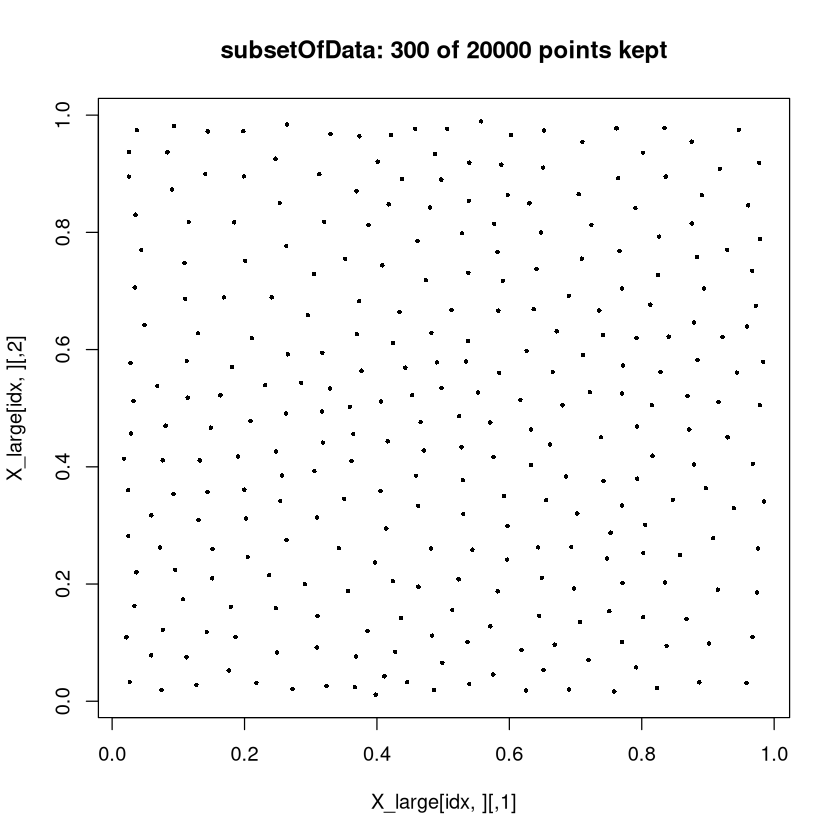

In [9]:
n_large <- 20000
X_large <- matrix(runif(2 * n_large), ncol = 2)
y_large <- branin(X_large)

t_subset <- system.time(idx <- subsetOfData(X_large, 300))["elapsed"]
cat(sprintf("subsetOfData(%d -> %d): %.2f s\n", n_large, length(idx), t_subset))

t_fit_subset <- system.time(
  k_subset <- Kriging(y_large[idx], X_large[idx, ], kernel = "matern5_2", objective = "LL")
)["elapsed"]

p_subset <- predict(k_subset, grid_pts, return_stdev = FALSE)
cat(sprintf("fit LL on subset (%d pts): %.1f s\n", length(idx), t_fit_subset))
cat("RMSE vs true (subsetOfData + exact LL):", sqrt(mean((p_subset$mean - as.vector(z_true))^2)), "\n")

plot(X_large[idx, ], pch = 16, cex = 0.5, main = sprintf("subsetOfData: %d of %d points kept", length(idx), n_large))

## Notes

- `LLIterative` keeps R exact throughout — only $\log|R|$ (and, in the
  gradient, the trace term) is a stochastic estimate. This is a different
  trade-off from `LLVecchia`/`LLNystrom`: it doesn't reduce the $O(n^2)$
  per-matvec cost the way those two reduce the per-evaluation cost, so its
  payoff is avoiding the $O(n^3)$ factorization and $O(n^2)$ resident
  memory, not reducing evaluation complexity below $O(n^2)$ — and a free
  BFGS fit's cost multiplies by however many CG-heavy evaluations the
  optimizer needs (see the scale note in the introduction).
- Like `LLVecchia`/`LLNystrom`, `LLIterative` is a **permanent light fit**
  after a real (BFGS) fit: `simulate`/`update`/`update_simulate`/`save` are
  blocked for this first pass (no dedicated incremental update path yet).
- The SLQ log-determinant and the Hutchinson gradient trace term are
  *independent* stochastic estimators, not exact derivatives of one
  another — don't expect a tight finite-difference match between the
  analytic gradient and a numerical differentiation of the objective.
- `predictIterative`'s `return_stdev=TRUE` cost is per-prediction-point — fine for
  a handful of points (§7), a poor fit for a full prediction grid (§5 uses
  mean only, on purpose).
- References: Ubaru, Chen & Saad (2017), *SIAM J. Matrix Anal. Appl.*;
  Hutchinson (1990), *Comm. Statist. Simulation Comput.*; Gardner et al.
  (2018), *NeurIPS* (GPyTorch/BBMM — the strategy this objective mirrors).
- See `docs/math/Iterative.md`, `docs/math/PredictIterative.md` and
  `docs/math/SubsetOfData.md` for the full derivations.
